In [62]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv


In [63]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv')

In [65]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


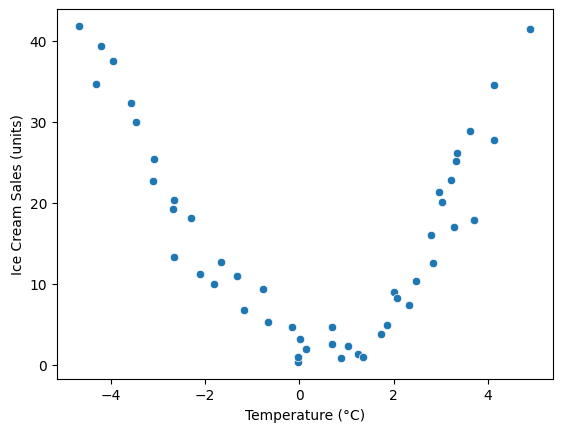

In [67]:
sns.scatterplot(x=df['Temperature (°C)'],y=df['Ice Cream Sales (units)'])
plt.show()

## Now see here , the data is non linear , so in this type of dataset , LinearRegression is not performing well , so lets try both of them and do comparision and choose best model

In [68]:
x=df.iloc[:,0:1]
y=df.iloc[:,1:]

In [69]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [70]:
model = LinearRegression()

In [71]:
model.fit(x_train,y_train)

LinearRegression()

In [72]:
y_pred = model.predict(x_test)
print ('Accuracy :',r2_score(y_test,y_pred))

Accuracy : -0.5751270190188227


## Regression Line

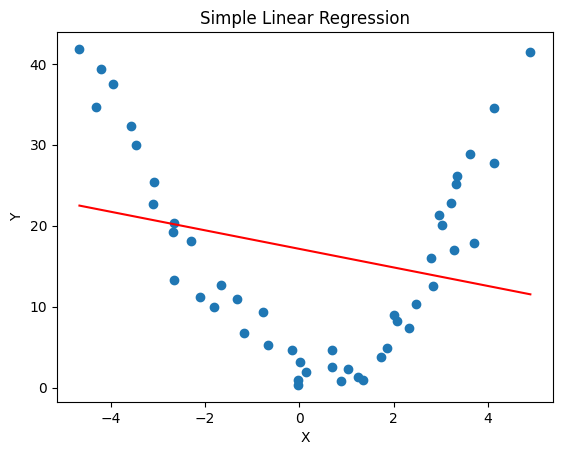

In [74]:
# Simple Linear Regression Plot

y_pred_linear = model.predict(x)

plt.scatter(x, y)

plt.plot(x, y_pred_linear, color='red')

plt.title("Simple Linear Regression")

plt.xlabel("X")

plt.ylabel("Y")

plt.show()

# Polynomial Regression

In [35]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2)

In [36]:
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [37]:
model . fit(x_train_trans,y_train)

LinearRegression()

## Now see Here The difference between the result

In [40]:
y_pred_new = model.predict(x_test_trans)
print ('Accuracy :',r2_score(y_test,y_pred_new))


Accuracy : 0.843055137193884


## Scatter Plot

In [79]:

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(x_train)

X_poly_all = poly.transform(x)

# Train Model on Polynomial Features

model = LinearRegression()

model.fit(X_train_poly, y_train)

# Predict

y_pred_poly = model.predict(X_poly_all)

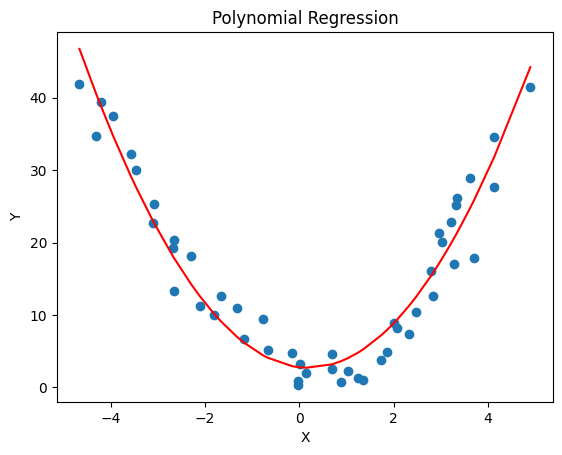

In [80]:

sorted_index = x.values.flatten().argsort()

X_sorted = x.values[sorted_index]

y_sorted = y_pred_poly[sorted_index]

plt.scatter(x, y)

plt.plot(X_sorted, y_sorted, color='red')

plt.title("Polynomial Regression")

plt.xlabel("X")

plt.ylabel("Y")

plt.show()

### Scatter plot for showing the proper curve which try to cover each every point , thats can not possible using the simpler linear Regression